# Trader Behavior vs Market Sentiment Analysis

### Candidate: Aayush Narwade  
### Role: Data Analyst / Data Science  

---

## Objective
To analyze the relationship between **trader performance** and **market sentiment (Fear & Greed Index)**, and uncover behavioral patterns that can inform smarter trading strategies.

---

## Key Questions
- How does market sentiment affect trader profitability?
- Do traders behave differently in Fear vs Greed?
- Is trading activity driven by rational strategy or emotional reactions?
- What differentiates top traders from average traders?


---
## Hypothesis

We explore the following hypotheses:

1. **H1:** Traders perform better during Fear due to higher volatility

2. **H2:** Trading activity increases during Fear (panic-driven behavior)  

3. **H3:** Traders exhibit a "buy-the-dip" bias during Fear  

4. **H4:** High profitability is driven by a few large trades, not consistency  

5. **H5:** Top traders behave differently from average traders  

---


In [12]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [15]:
#Initialize Dataframes
df_trades = pd.read_csv("historical_data.csv")
df_sentiment = pd.read_csv("fear_greed_index.csv")

## Data Cleaning & Preprocessing

- Converted timestamps to datetime format
- Standardized column names
- Created derived features (profit flag, long/short indicator)
- Aggregated trade-level data into daily trader-level metrics

In [16]:
# Standardize column names
df_trades.columns = df_trades.columns.str.strip().str.lower().str.replace(' ', '_')
df_sentiment.columns = df_sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert timestamps
df_trades['timestamp_ist'] = pd.to_datetime(df_trades['timestamp_ist'].str.strip(), format='%d-%m-%Y %H:%M')
df_trades['date'] = df_trades['timestamp_ist'].dt.date

df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date

# Feature engineering
df_trades['is_profit'] = df_trades['closed_pnl'] > 0
df_trades['is_long'] = df_trades['side'].str.lower().apply(lambda x: 1 if x == 'buy' else 0)

In [20]:
df_daily = df_trades.groupby(['account', 'date']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'sum',
    'execution_price': 'mean',
    'is_profit': 'mean',
    'is_long': 'mean',
    'fee': 'sum'
}).reset_index()

df_daily = df_daily.rename(columns={
    'closed_pnl': 'daily_pnl',
    'size_usd': 'total_volume',
    'execution_price': 'avg_price',
    'is_profit': 'win_rate',
    'is_long': 'long_ratio',
    'fee': 'total_fees'
})

df_daily.head()

,account,date,daily_pnl,total_volume,avg_price,win_rate,long_ratio,total_fees
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,3204.461017,0.000000,0.000000,167.796055
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,653.365147,0.000000,0.000000,67.883615
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,3164.600000,0.000000,0.000000,94.937983
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,338240.00,3382.400000,0.000000,1.000000,33.823995
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,465700.00,232.921111,0.444444,0.444444,104.622490


In [18]:
# merge with sentiment data
df_final = df_daily.merge(df_sentiment, on='date', how='left')

In [22]:
print(df_final.describe())
df_final['classification'].value_counts()

           daily_pnl  total_volume      avg_price     win_rate   long_ratio  \
count    2341.000000  2.341000e+03    2341.000000  2341.000000  2341.000000   
mean     4398.530091  5.088370e+05   14509.967892     0.359926     0.489142   
std     28415.938999  2.413745e+06   29558.424507     0.343601     0.364306   
min   -358963.139984  0.000000e+00       0.000005     0.000000     0.000000   
25%         0.000000  1.576401e+04       5.744733     0.000000     0.142857   
50%       207.983482  6.935739e+04      27.621429     0.318182     0.486486   
75%      1842.839943  2.507812e+05    5998.727154     0.608000     0.833333   
max    533974.662903  5.125045e+07  107109.750000     1.000000     1.000000   

         total_fees     timestamp        value  
count   2341.000000  2.340000e+03  2340.000000  
mean     105.022521  1.734850e+09    54.852137  
std      461.394026  1.039061e+07    20.619321  
min       -4.847684  1.682919e+09    10.000000  
25%        2.982829  1.732772e+09    34.000

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64

## Initial Observations

- Profitability is highly skewed (few large winners dominate)
- Average win rate is low (~36%), indicating inefficient trading
- Traders exhibit mixed long/short behavior, with some extreme biases
- Trading fees are significant, especially during high activity periods

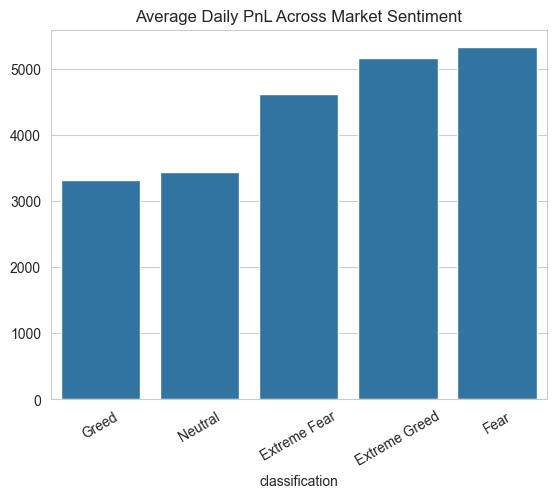

In [23]:
sentiment_pnl = df_final.groupby('classification')['daily_pnl'].mean().sort_values()

plt.figure()
sns.barplot(x=sentiment_pnl.index, y=sentiment_pnl.values)

plt.title("Average Daily PnL Across Market Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight

- Profitability appears higher during Fear regimes  
- However, this is driven by a small number of large trades (skewed distribution)  
- Indicates volatility-driven gains rather than consistent strategy

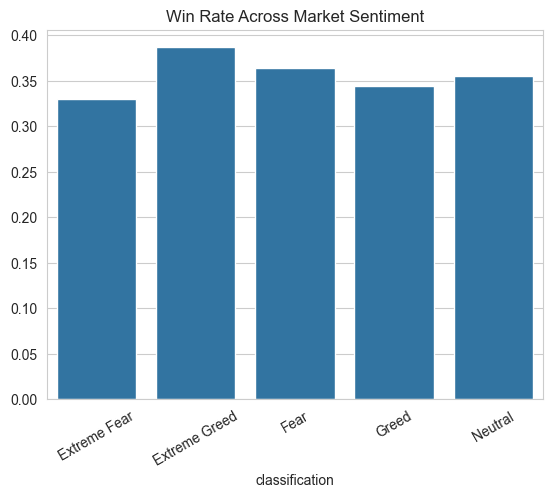

In [24]:
sentiment_winrate = df_final.groupby('classification')['win_rate'].mean()

plt.figure()
sns.barplot(x=sentiment_winrate.index, y=sentiment_winrate.values)

plt.title("Win Rate Across Market Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight

- Win rates are lowest during Extreme Fear  
- Traders lose more frequently in volatile markets  
- Suggests emotional or reactive trading behavior

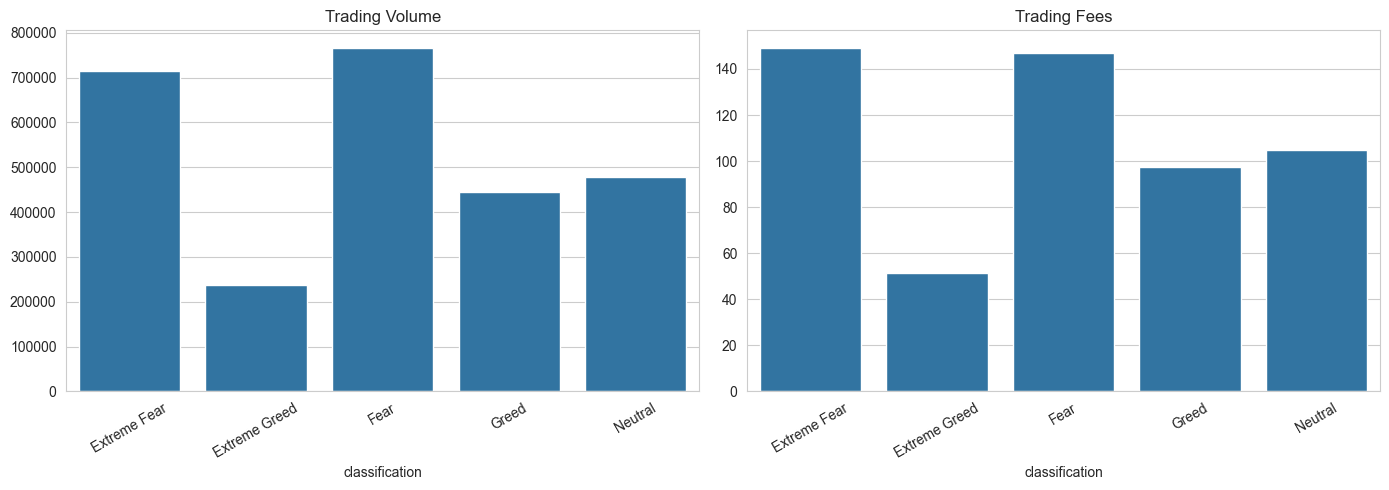

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True)

# Volume
sns.barplot(x=sentiment_volume.index, y=sentiment_volume.values, ax=axes[0])
axes[0].set_title("Trading Volume")
axes[0].tick_params(axis='x', rotation=30)

# Fees
sns.barplot(x=sentiment_fees.index, y=sentiment_fees.values, ax=axes[1])
axes[1].set_title("Trading Fees")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Insight

- Both trading volume and fees peak during Fear regimes  
- This confirms that increased activity directly leads to higher transaction costs  
- Indicates panic-driven overtrading rather than strategic execution

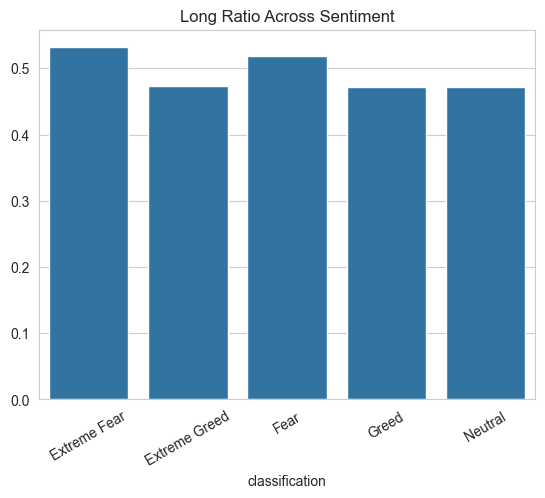

In [29]:
sentiment_long = df_final.groupby('classification')['long_ratio'].mean()

plt.figure()
sns.barplot(x=sentiment_long.index, y=sentiment_long.values)

plt.title("Long Ratio Across Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight

- Traders increase long positions during Fear  
- Indicates a “buy-the-dip” strategy  
- However, combined with low win rates, this strategy is often unsuccessful

In [31]:
top_traders = df_final.groupby('account')['daily_pnl'].sum().sort_values(ascending=False).head(20)
top_accounts = top_traders.index

df_top = df_final[df_final['account'].isin(top_accounts)]

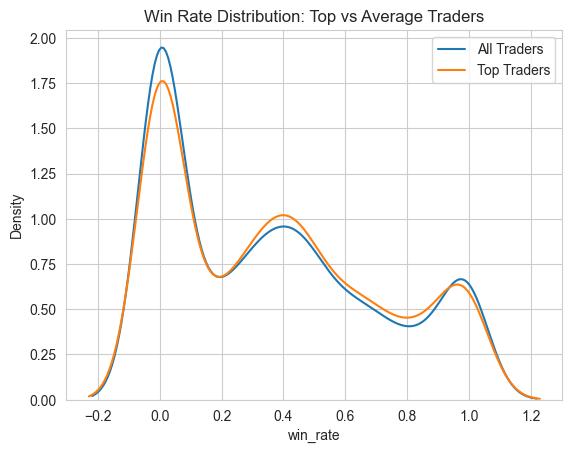

In [32]:
plt.figure()

sns.kdeplot(df_final['win_rate'], label='All Traders')
sns.kdeplot(df_top['win_rate'], label='Top Traders')

plt.title("Win Rate Distribution: Top vs Average Traders")
plt.legend()
plt.show()

### Insight

- Top traders demonstrate more consistent performance  
- They likely manage risk better and avoid overtrading  
- Suggests disciplined strategy vs emotional trading in average traders

## Final Conclusions

1. **Fear drives trading activity, not Greed**
   - Traders are most active during Fear, indicating emotional reactions

2. **Profitability is driven by volatility, not consistency**
   - Large profits occur during Fear but with low win rates

3. **Behavioral bias: buying during Fear**
   - Traders attempt to catch market reversals but often fail

4. **Fees significantly impact performance**
   - Overtrading during Fear leads to higher costs

5. **Top traders behave differently**
   - More consistent, disciplined, and less reactive

---

## Strategic Implications

- Avoid overtrading during volatile markets  
- Focus on risk management rather than frequency  
- Contrarian strategies may work, but require discipline  